# Klasyfikacja obrazów CIFAR-10 za pomocą Custom CNN (Grupa B)
Implementacja od podstaw sieci konwolucyjnej (CNN) w bibliotece PyTorch do klasyfikacji 10 klas obrazów ze zbioru CIFAR-10. Zadanie obejmuje analizę danych, budowę architektury, przeprowadzenie serii eksperymentów badających wpływ hiperparametrów (Learning Rate, Batch Size, Kernel Size oraz Pooling) oraz ocenę końcową najlepszego modelu.

## 1. Import bibliotek

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import copy

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Używane urządzenie: {device}')

Używane urządzenie: cuda


## 2. Analiza zbioru danych CIFAR-10
Zbiór CIFAR-10 składa się z 60 000 kolorowych obrazów o wymiarach 32x32 piksele, podzielonych na 10 klas (po 6000 obrazów na klasę). W tej sekcji pobierzemy dane i sprawdzimy ich podstawowe statystyki oraz wyświetlimy przykłady.

100%|██████████| 170M/170M [00:03<00:00, 48.6MB/s]


Liczba obrazów treningowych: 50000
Liczba obrazów testowych: 10000
Wymiary pojedynczego obrazu: torch.Size([3, 32, 32]) (Kanały x Wysokość x Szerokość)
Zakres wartości pikseli: min = 0.00, max = 1.00
Rozkład klas w zbiorze treningowym: {'plane': 5000, 'car': 5000, 'bird': 5000, 'cat': 5000, 'deer': 5000, 'dog': 5000, 'frog': 5000, 'horse': 5000, 'ship': 5000, 'truck': 5000}


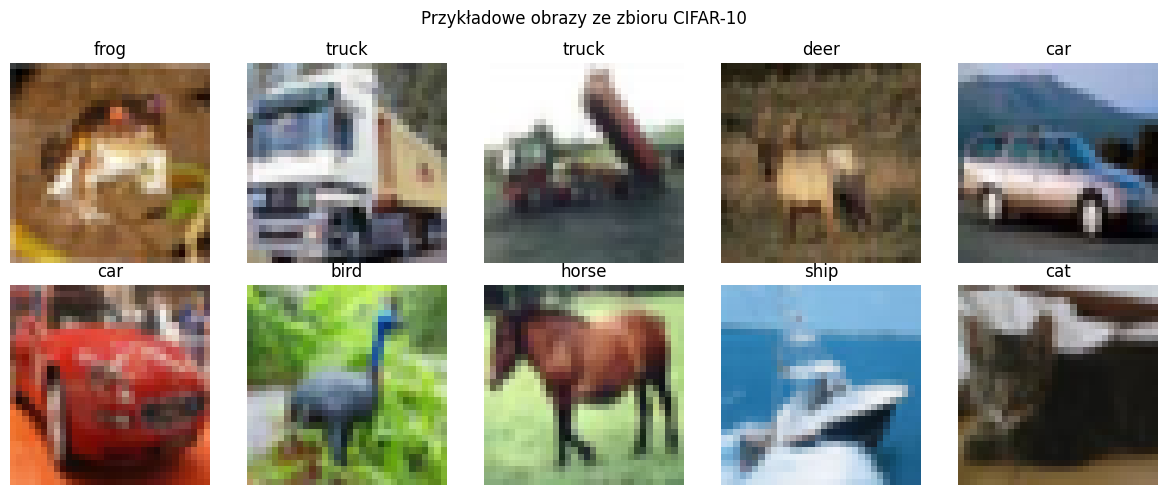

In [ ]:
# Transformacje: na razie tylko zamiana na tensor, aby przeanalizować surowe wartości
transform_raw = transforms.Compose([transforms.ToTensor()])

trainset_raw = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_raw)
testset_raw = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_raw)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# Statystyki i analiza
print(f"Liczba obrazów treningowych: {len(trainset_raw)}")
print(f"Liczba obrazów testowych: {len(testset_raw)}")
print(f"Wymiary pojedynczego obrazu: {trainset_raw[0][0].shape} (Kanały x Wysokość x Szerokość)")

# Zakres wartości pikseli
sample_image = trainset_raw[0][0]
print(f"Zakres wartości pikseli: min = {sample_image.min().item():.2f}, max = {sample_image.max().item():.2f}")

# Rozkład klas
class_counts = {cls: 0 for cls in classes}
for _, label in trainset_raw:
    class_counts[classes[label]] += 1
print(f"Rozkład klas w zbiorze treningowym: {class_counts}")

# Wizualizacja przykładowych obrazów
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img, label = trainset_raw[i]
    # Konwersja (C, H, W) -> (H, W, C) do wyświetlenia w matplotlib
    img_np = np.transpose(img.numpy(), (1, 2, 0))
    ax.imshow(img_np)
    ax.set_title(classes[label])
    ax.axis('off')
plt.suptitle("Przykładowe obrazy ze zbioru CIFAR-10")
plt.tight_layout()
plt.show()

## 3. Architektura sieci neuronowej (Grupa B - CNN)

Zgodnie z wymaganiami grupy, zaimplementowano sieć konwolucyjną posiadającą dwie warstwy konwolucyjne (`Conv2d`).
Aby ułatwić Serię 3 eksperymentów, sieć została sparametryzowana:
* `kernel_size`: pozwala na zmianę rozmiaru filtra (np. 3x3, 5x5).
* `pool_type`: pozwala na przełączanie między MaxPool, AvgPool a brakiem poolingu (Identity).

Sieć automatycznie przelicza rozmiar danych wejściowych do warstwy w pełni połączonej (`Linear`), co zapewnia elastyczność przy zmianie hiperparametrów.

In [8]:
class CustomCNN(nn.Module):
    def __init__(self, kernel_size=3, pool_type='max'):
        super(CustomCNN, self).__init__()

        # Utrzymanie tych samych wymiarów przestrzennych (padding = kernel_size // 2)
        pad = kernel_size // 2

        # 1. Warstwa konwolucyjna (wejście: 3 kanały, wyjście: 16 filtrów)
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=kernel_size, padding=pad)

        # 2. Warstwa konwolucyjna (wejście: 16 kanałów, wyjście: 32 filtry)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=kernel_size, padding=pad)

        # Mechanizm poolingu
        if pool_type == 'max':
            self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        elif pool_type == 'avg':
            self.pool = nn.AvgPool2d(kernel_size=2, stride=2)
        else:
            self.pool = nn.Identity() # Brak poolingu

        # Automatyczne obliczenie wejścia do warstwy Linear
        dummy_input = torch.zeros(1, 3, 32, 32)
        x = self.pool(self.conv1(dummy_input))
        x = self.pool(self.conv2(x))
        linear_input_size = x.view(-1).shape[0]

        # Warstwy w pełni połączone (Dense)
        self.fc1 = nn.Linear(linear_input_size, 128)
        self.fc2 = nn.Linear(128, 10) # 10 wyjść dla 10 klas

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1) # Spłaszczenie
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

## 4. Funkcje pomocnicze do uczenia i ewaluacji
Tworzymy funkcję `train_model`, która zajmie się pętlą uczenia oraz zapisywaniem wyników. Dodatkowo definiujemy nową transformację z normalizacją danych, aby przyspieszyć proces uczenia.


In [11]:
# Normalizacja danych (wartości średnie i odchylenia standardowe dla CIFAR-10)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=False, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=False, transform=transform)

def train_model(model, trainloader, testloader, criterion, optimizer, epochs=5):
    history = {'train_acc': [], 'test_acc': []}

    for epoch in range(epochs):
        model.train()
        correct_train, total_train = 0, 0

        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        train_acc = 100 * correct_train / total_train

        # Ewaluacja (Test)
        model.eval()
        correct_test, total_test = 0, 0
        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total_test += labels.size(0)
                correct_test += (predicted == labels).sum().item()

        test_acc = 100 * correct_test / total_test
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)

        print(f"Epoka {epoch+1}/{epochs} | Dokładność Train: {train_acc:.2f}% | Dokładność Test: {test_acc:.2f}%")

    return history

RuntimeError: Dataset not found or corrupted. You can use download=True to download it

## 5. Eksperymenty

W poniższych sekcjach wykonujemy po 5 epok uczenia.

### Seria 1: Wpływ Learning Rate
Współczynnik uczenia (Learning Rate) decyduje o tym, jak duże kroki robi model podczas aktualizacji wag. Testujemy wartości: 0.0001, 0.001, 0.01. Użyjemy optymalizatora Adam, domyślnego Batch Size = 64, Kernel = 3, Pool = max.



--- Trening dla Learning Rate = 0.0001 ---
Epoka 1/5 | Dokładność Train: 38.74% | Dokładność Test: 46.63%
Epoka 2/5 | Dokładność Train: 48.70% | Dokładność Test: 51.09%
Epoka 3/5 | Dokładność Train: 52.55% | Dokładność Test: 53.45%
Epoka 4/5 | Dokładność Train: 55.20% | Dokładność Test: 55.75%
Epoka 5/5 | Dokładność Train: 57.18% | Dokładność Test: 56.62%

--- Trening dla Learning Rate = 0.001 ---
Epoka 1/5 | Dokładność Train: 48.63% | Dokładność Test: 57.75%
Epoka 2/5 | Dokładność Train: 62.13% | Dokładność Test: 65.40%
Epoka 3/5 | Dokładność Train: 67.90% | Dokładność Test: 66.35%
Epoka 4/5 | Dokładność Train: 71.41% | Dokładność Test: 69.29%
Epoka 5/5 | Dokładność Train: 74.15% | Dokładność Test: 65.99%

--- Trening dla Learning Rate = 0.01 ---
Epoka 1/5 | Dokładność Train: 33.46% | Dokładność Test: 38.93%
Epoka 2/5 | Dokładność Train: 40.20% | Dokładność Test: 40.33%
Epoka 3/5 | Dokładność Train: 43.14% | Dokładność Test: 43.64%
Epoka 4/5 | Dokładność Train: 45.97% | Dokładność Te

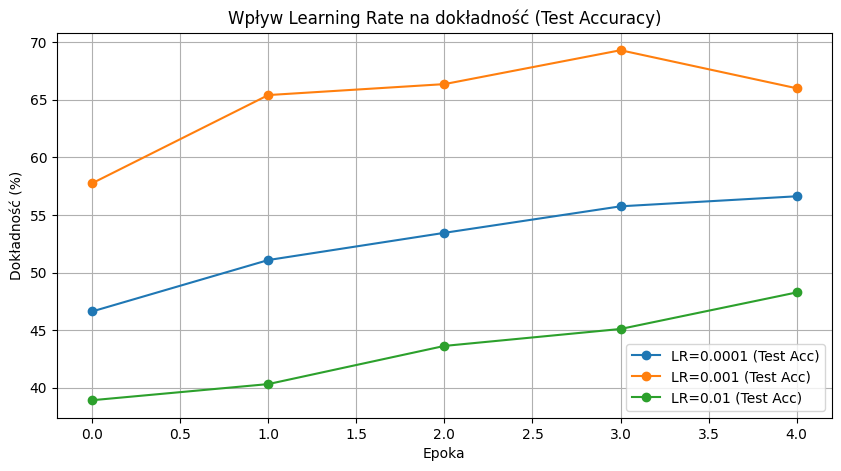

In [ ]:
learning_rates = [0.0001, 0.001, 0.01]
results_lr = {}
batch_size_default = 64

# Przygotowanie paczek danych
trainloader_default = torch.utils.data.DataLoader(trainset, batch_size=batch_size_default, shuffle=True)
testloader_default = torch.utils.data.DataLoader(testset, batch_size=batch_size_default, shuffle=False)

for lr in learning_rates:
    print(f"\n--- Trening dla Learning Rate = {lr} ---")
    model_lr = CustomCNN(kernel_size=3, pool_type='max').to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model_lr.parameters(), lr=lr)

    hist = train_model(model_lr, trainloader_default, testloader_default, criterion, optimizer, epochs=5)
    results_lr[lr] = hist

# Rysowanie wykresów po zakończeniu pętli
plt.figure(figsize=(10, 5))
for lr, hist in results_lr.items():
    plt.plot(hist['test_acc'], label=f'LR={lr} (Test Acc)', marker='o')
plt.title('Wpływ Learning Rate na dokładność (Test Accuracy)')
plt.xlabel('Epoka')
plt.ylabel('Dokładność (%)')
plt.legend()
plt.grid(True)
plt.show()

**Wniosek (Seria 1):** Z eksperymentu wynika, że współczynnik uczenia `LR=0.001` pozwala osiągnąć najlepsze rezultaty (najszybszy wzrost dokładności, sięgający prawie 70%). Mniejszy krok (`0.0001`) powoduje, że sieć uczy się zbyt wolno, natomiast zbyt duży (`0.01`) sprawia, że optymalizator nie potrafi precyzyjnie znaleźć optymalnego minimum, co daje najgorszą dokładność. W kolejnych eksperymentach przyjmujemy optymalne `LR=0.001`.

---

### Seria 2: Wpływ Batch Size
Zbadamy wpływ rozmiaru paczki (Batch Size) na proces uczenia. Użyjemy optymalnego LR z poprzedniego kroku (0.001). Testowane wartości: 16, 64, 128.


--- Trening dla Batch Size = 16 ---
Epoka 1/5 | Dokładność Train: 53.42% | Dokładność Test: 63.02%
Epoka 2/5 | Dokładność Train: 65.84% | Dokładność Test: 66.20%
Epoka 3/5 | Dokładność Train: 70.41% | Dokładność Test: 67.19%
Epoka 4/5 | Dokładność Train: 73.72% | Dokładność Test: 67.83%
Epoka 5/5 | Dokładność Train: 76.59% | Dokładność Test: 67.28%

--- Trening dla Batch Size = 64 ---
Epoka 1/5 | Dokładność Train: 50.13% | Dokładność Test: 59.70%
Epoka 2/5 | Dokładność Train: 62.70% | Dokładność Test: 64.08%
Epoka 3/5 | Dokładność Train: 67.90% | Dokładność Test: 67.08%
Epoka 4/5 | Dokładność Train: 71.05% | Dokładność Test: 67.70%
Epoka 5/5 | Dokładność Train: 73.65% | Dokładność Test: 69.40%

--- Trening dla Batch Size = 128 ---
Epoka 1/5 | Dokładność Train: 47.95% | Dokładność Test: 56.68%
Epoka 2/5 | Dokładność Train: 60.97% | Dokładność Test: 63.48%
Epoka 3/5 | Dokładność Train: 65.95% | Dokładność Test: 64.93%
Epoka 4/5 | Dokładność Train: 69.76% | Dokładność Test: 67.64%
Epoka 

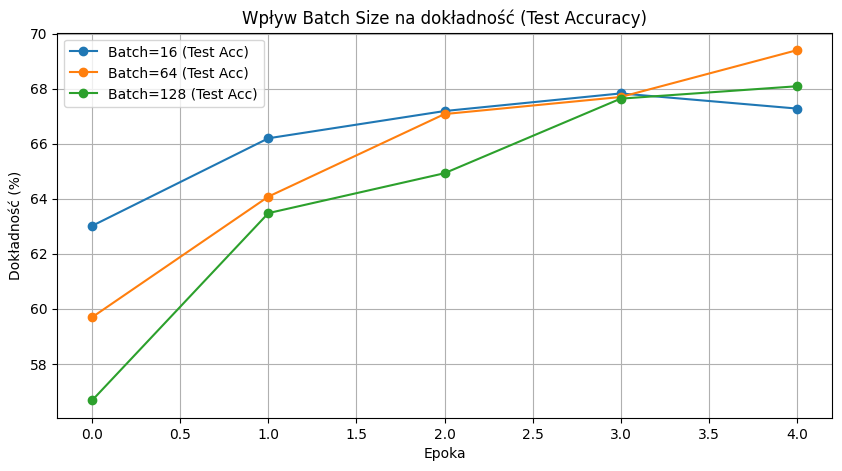

In [ ]:
batch_sizes = [16, 64, 128]
results_bs = {}

for bs in batch_sizes:
    print(f"\n--- Trening dla Batch Size = {bs} ---")
    trainloader_bs = torch.utils.data.DataLoader(trainset, batch_size=bs, shuffle=True)
    testloader_bs = torch.utils.data.DataLoader(testset, batch_size=bs, shuffle=False)

    model_bs = CustomCNN(kernel_size=3, pool_type='max').to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model_bs.parameters(), lr=0.001)

    hist = train_model(model_bs, trainloader_bs, testloader_bs, criterion, optimizer, epochs=5)
    results_bs[bs] = hist

# Rysowanie wykresów
plt.figure(figsize=(10, 5))
for bs, hist in results_bs.items():
    plt.plot(hist['test_acc'], label=f'Batch={bs} (Test Acc)', marker='o')
plt.title('Wpływ Batch Size na dokładność (Test Accuracy)')
plt.xlabel('Epoka')
plt.ylabel('Dokładność (%)')
plt.legend()
plt.grid(True)
plt.show()

**Wniosek (Seria 2):** Z wykresu wynika, że bardzo mały rozmiar paczki (Batch=16) uczy się szybko na początku, ale w późniejszych epokach staje się niestabilny i jego dokładność na zbiorze testowym spada (tzw. overfitting). Z kolei największa paczka (Batch=128) uczy się najwolniej. Złotym środkiem okazał się `Batch Size = 64`, który uczył się stabilnie i osiągnął najwyższą końcową dokładność (ponad 69%). W kolejnych eksperymentach przyjmujemy tę wartość.

---

### Seria 3: Wpływ parametrów Grupy B (Rozmiar Kernela oraz Pooling)
Zgodnie z wymogami Grupy B, wykonamy dwa powiązane eksperymenty badające kluczowe elementy warstw konwolucyjnych.

**A) Wpływ rozmiaru filtra (Kernel Size): 3, 5, 7** (przy optymalnych: LR=0.001, Batch=64).


--- Trening dla Kernel Size = 3 ---
Epoka 1/5 | Dokładność Train: 50.48% | Dokładność Test: 60.61%
Epoka 2/5 | Dokładność Train: 63.55% | Dokładność Test: 63.23%
Epoka 3/5 | Dokładność Train: 68.54% | Dokładność Test: 67.14%
Epoka 4/5 | Dokładność Train: 71.99% | Dokładność Test: 67.24%
Epoka 5/5 | Dokładność Train: 74.89% | Dokładność Test: 69.42%

--- Trening dla Kernel Size = 5 ---
Epoka 1/5 | Dokładność Train: 50.77% | Dokładność Test: 61.04%
Epoka 2/5 | Dokładność Train: 64.47% | Dokładność Test: 65.37%
Epoka 3/5 | Dokładność Train: 69.73% | Dokładność Test: 66.80%
Epoka 4/5 | Dokładność Train: 73.63% | Dokładność Test: 67.92%
Epoka 5/5 | Dokładność Train: 76.59% | Dokładność Test: 69.85%

--- Trening dla Kernel Size = 7 ---
Epoka 1/5 | Dokładność Train: 50.32% | Dokładność Test: 59.83%
Epoka 2/5 | Dokładność Train: 63.84% | Dokładność Test: 64.34%
Epoka 3/5 | Dokładność Train: 69.35% | Dokładność Test: 66.65%
Epoka 4/5 | Dokładność Train: 73.42% | Dokładność Test: 67.40%
Epoka 5

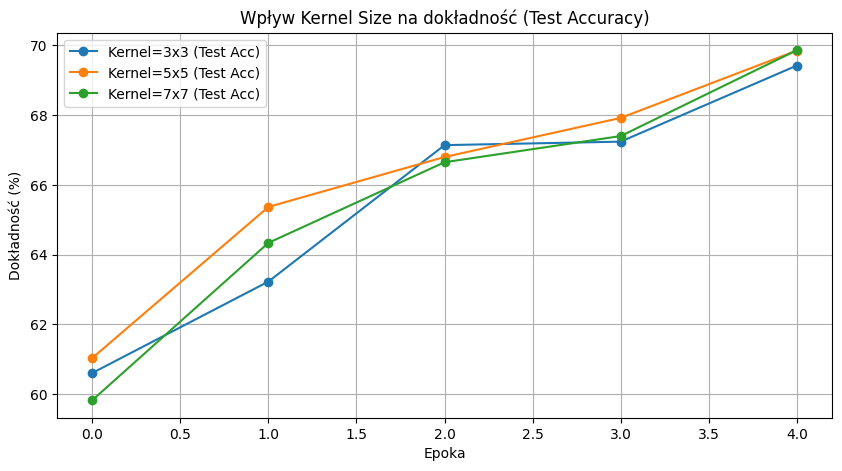

In [ ]:
kernel_sizes = [3, 5, 7]
results_ks = {}

for ks in kernel_sizes:
    print(f"\n--- Trening dla Kernel Size = {ks} ---")
    model_ks = CustomCNN(kernel_size=ks, pool_type='max').to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model_ks.parameters(), lr=0.001)

    hist = train_model(model_ks, trainloader_default, testloader_default, criterion, optimizer, epochs=5)
    results_ks[ks] = hist

plt.figure(figsize=(10, 5))
for ks, hist in results_ks.items():
    plt.plot(hist['test_acc'], label=f'Kernel={ks}x{ks} (Test Acc)', marker='o')
plt.title('Wpływ Kernel Size na dokładność (Test Accuracy)')
plt.xlabel('Epoka')
plt.ylabel('Dokładność (%)')
plt.legend()
plt.grid(True)
plt.show()

**Wniosek (Seria 3A - Kernel Size):** Wyniki wskazują, że dla naszego modelu różnice pomiędzy rozmiarami filtra 3x3, 5x5 i 7x7 są po 5 epokach minimalne (wszystkie osiągają blisko 69-70% dokładności na zbiorze testowym). W praktyce często wybiera się 3x3 ze względu na mniejszą liczbę parametrów do wyuczenia i szybsze obliczenia. Z tego powodu w dalszych krokach zostajemy przy `Kernel = 3`.

---

**Rodzaj Poolingu: MaxPool, AvgPool, Brak poolingu (None)** (przy Kernel=3, LR=0.001, Batch=64)
W tym eksperymencie sprawdzimy, jak sposób redukcji wymiarów (kompresji cech) wpływa na uczenie. Przy okazji zapiszemy w pamięci model z najlepszymi parametrami (`best_model`), aby użyć go w końcowej ewaluacji.


--- Trening dla Poolingu = max ---
Epoka 1/5 | Train: 50.63% | Test: 59.29%
Epoka 2/5 | Train: 63.70% | Test: 64.29%
Epoka 3/5 | Train: 68.65% | Test: 66.42%
Epoka 4/5 | Train: 71.69% | Test: 68.24%
Epoka 5/5 | Train: 74.43% | Test: 70.18%

--- Trening dla Poolingu = avg ---
Epoka 1/5 | Train: 46.49% | Test: 54.45%
Epoka 2/5 | Train: 58.72% | Test: 60.95%
Epoka 3/5 | Train: 64.09% | Test: 62.88%
Epoka 4/5 | Train: 68.18% | Test: 66.51%
Epoka 5/5 | Train: 71.01% | Test: 68.16%

--- Trening dla Poolingu = none ---
Epoka 1/5 | Train: 52.99% | Test: 62.79%
Epoka 2/5 | Train: 68.80% | Test: 65.28%
Epoka 3/5 | Train: 78.02% | Test: 65.81%
Epoka 4/5 | Train: 87.04% | Test: 64.51%
Epoka 5/5 | Train: 93.60% | Test: 63.80%


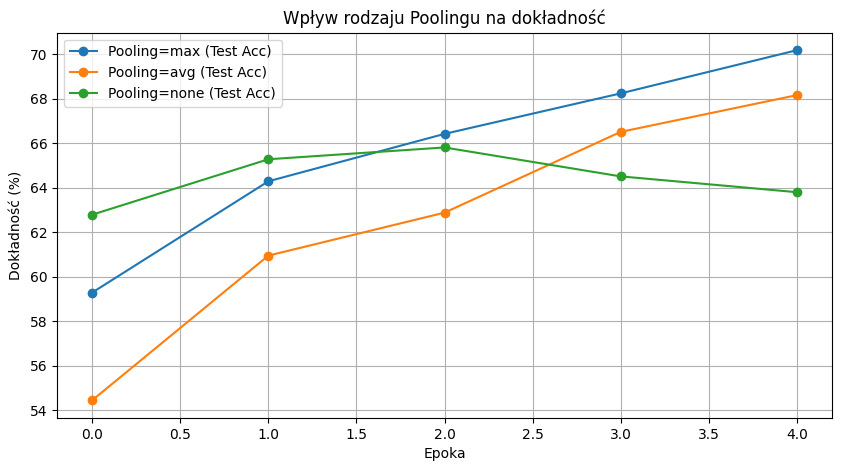

In [15]:
pool_types = ['max', 'avg', 'none']
results_pool = {}

for pt in pool_types:
    print(f"\n--- Trening dla Poolingu = {pt} ---")
    model_pool = CustomCNN(kernel_size=3, pool_type=pt).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model_pool.parameters(), lr=0.001)

    hist = train_model(model_pool, trainloader_default, testloader_default, criterion, optimizer, epochs=5)
    results_pool[pt] = hist

    # Zapiszmy najlepszy model do końcowej ewaluacji (wybieramy max pooling jako nasz bazowy)
    if pt == 'max':
        best_model = copy.deepcopy(model_pool)

plt.figure(figsize=(10, 5))
for pt, hist in results_pool.items():
    plt.plot(hist['test_acc'], label=f'Pooling={pt} (Test Acc)', marker='o')
plt.title('Wpływ rodzaju Poolingu na dokładność')
plt.xlabel('Epoka')
plt.ylabel('Dokładność (%)')
plt.legend()
plt.grid(True)
plt.show()

## 6. Ewaluacja końcowa najlepszego modelu
Do końcowej oceny wykorzystujemy model z parametrami, które okazały się najskuteczniejsze: `LR=0.001`, `Batch=64`, `Kernel=3`, `Pool=max`. Wyświetlimy raport klasyfikacji, macierz pomyłek (confusion matrix) oraz przykłady obrazów, na których nasza sieć się pomyliła, aby zrozumieć charakter błędów.


--- Raport Klasyfikacji ---
              precision    recall  f1-score   support

       plane       0.68      0.78      0.73      1000
         car       0.81      0.82      0.82      1000
        bird       0.57      0.61      0.59      1000
         cat       0.57      0.45      0.50      1000
        deer       0.71      0.56      0.63      1000
         dog       0.63      0.59      0.61      1000
        frog       0.71      0.84      0.77      1000
       horse       0.73      0.78      0.76      1000
        ship       0.81      0.79      0.80      1000
       truck       0.76      0.79      0.77      1000

    accuracy                           0.70     10000
   macro avg       0.70      0.70      0.70     10000
weighted avg       0.70      0.70      0.70     10000



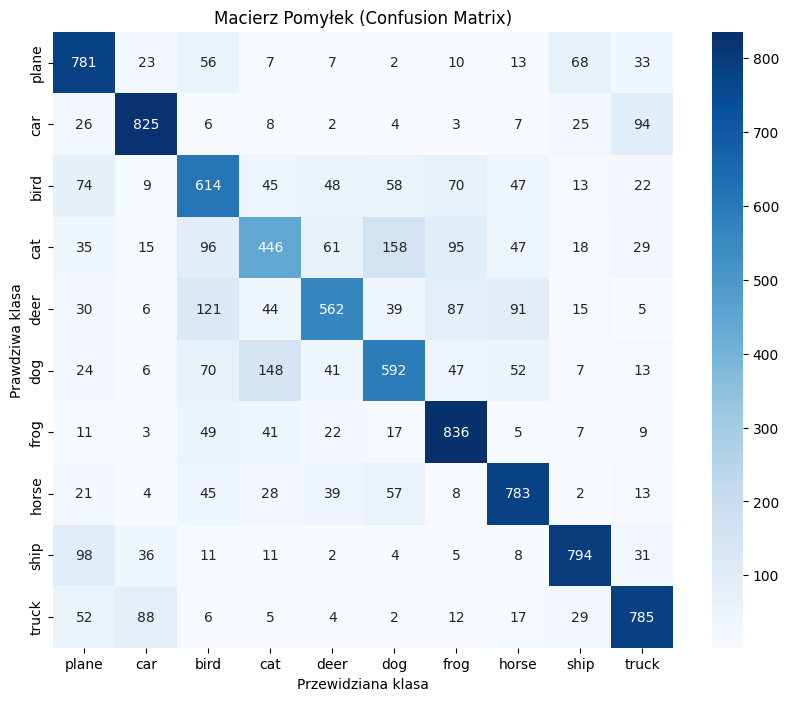


--- Przykładowe błędy klasyfikacji ---


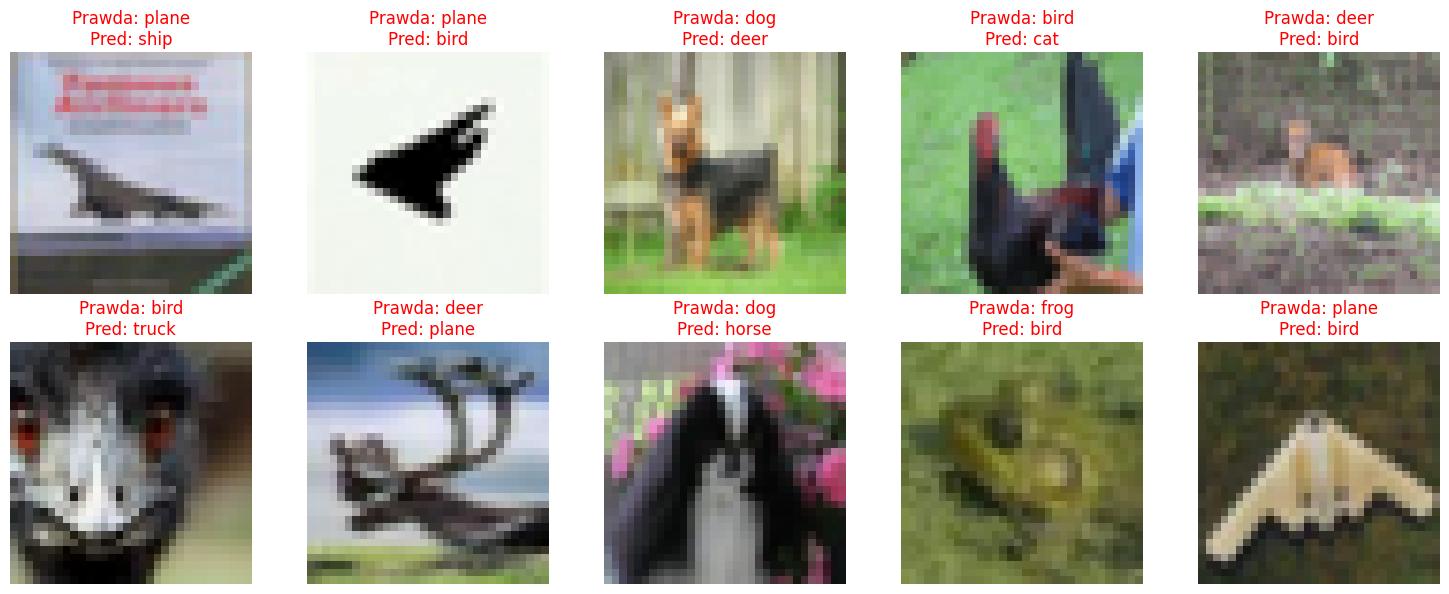

In [16]:
# Ustawiamy model w tryb ewaluacji
best_model.eval()
all_preds, all_labels = [], []
mis_img, mis_lbl, mis_prd = [], [], []

with torch.no_grad():
    for inputs, labels in testloader_default:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = best_model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        # Zbieranie pomyłek (maksymalnie 10 do wyświetlenia)
        wrong = (preds != labels)
        if wrong.any() and len(mis_img) < 10:
            idx = torch.where(wrong)[0]
            for i in idx:
                if len(mis_img) < 10:
                    mis_img.append(inputs[i].cpu())
                    mis_lbl.append(labels[i].cpu())
                    mis_prd.append(preds[i].cpu())

# 1. Raport Klasyfikacji (Precision, Recall, F1)
print("\n--- Raport Klasyfikacji ---")
print(classification_report(all_labels, all_preds, target_names=classes))

# 2. Macierz Pomyłek
plt.figure(figsize=(10,8))
sns.heatmap(confusion_matrix(all_labels, all_preds), annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Macierz Pomyłek (Confusion Matrix)')
plt.ylabel('Prawdziwa klasa')
plt.xlabel('Przewidziana klasa')
plt.show()

# 3. Wizualizacja błędów
def denorm(t):
    m = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    s = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)
    return (t * s + m).clamp(0, 1)

print("\n--- Przykładowe błędy klasyfikacji ---")
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    if i < len(mis_img):
        img = np.transpose(denorm(mis_img[i]).numpy(), (1, 2, 0))
        ax.imshow(img)
        ax.set_title(f"Prawda: {classes[mis_lbl[i]]}\nPred: {classes[mis_prd[i]]}", color='red')
    ax.axis('off')
plt.tight_layout()
plt.show()

### Podsumowanie i Wnioski Końcowe

Na podstawie wygenerowanego Raportu Klasyfikacji oraz Macierzy Pomyłek możemy wyciągnąć następujące wnioski:

1. **Skuteczność ogólna:** Zaimplementowana od podstaw dwuwarstwowa sieć konwolucyjna osiągnęła ogólną dokładność (accuracy) na poziomie **70%**. Biorąc pod uwagę brak zaawansowanych technik (takich jak Data Augmentation, Dropout czy BatchNorm) oraz limit 5 epok, jest to bardzo solidny wynik.
2. **Najlepsze klasy (Precision/Recall > 0.80):** Model najlepiej radzi sobie z rozpoznawaniem maszyn i pojazdów, takich jak samochody (`car`), statki (`ship`) oraz ciężarówki (`truck`). Mają one bardzo wyraźne, "geometryczne" cechy szczególne (koła, krawędzie, tło wody/drogi), które są łatwe do wychwycenia przez filtry konwolucyjne. Wysoką skuteczność osiągnęła również żaba (`frog`).
3. **Najsłabsze klasy (Problematyczne):** Największy problem dla sieci stanowi odróżnienie kotów (`cat`, recall=0.45, f1=0.50) oraz ptaków (`bird`). Patrząc na macierz pomyłek i wizualizacje błędów, można zauważyć, że koty są często mylone z psami (`dog`), a ptaki z płazami lub mniejszymi ssakami. Wynika to z faktu, że przy tak niskiej rozdzielczości (32x32 piksele) te zwierzęta współdzielą podobne mapy cech (kształty uszu, łap, podobne organiczne tekstury futra/piór).
4. **Wpływ architektury:** Przeprowadzone eksperymenty potwierdziły, że optymalny rozmiar filtra w pierwszych warstwach to `3x3`. Zastosowanie `MaxPoolingu` okazało się kluczowe dla redukcji szumu w tle i wyciągnięcia najważniejszych "krawędzi", podczas gdy całkowity brak poolingu szybko prowadził do dramatycznego przeuczenia (overfittingu) z powodu zbyt dużego wejścia do warstwy gęstej (Linear).
